## Decision Tree for Regression

The process of solving regression problem with decision tree using Scikit Learn is very similar to that of classification. However for regression we use DecisionTreeRegressor class of the tree library

In [1]:
path='https://frenzy86.s3.eu-west-2.amazonaws.com/fav/tecno/petrol_consumption.csv'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
dataset = pd.read_csv(path)
dataset


,Petrol_tax,Average_income,Paved_Highways,Population_Driver_licence(%),Petrol_Consumption
0,9.00,3571,1976,0.525,541
1,9.00,4092,1250,0.572,524
2,9.00,3865,1586,0.580,561
3,7.50,4870,2351,0.529,414
4,8.00,4399,431,0.544,410
5,10.00,5342,1333,0.571,457
6,8.00,5319,11868,0.451,344
7,8.00,5126,2138,0.553,467
8,8.00,4447,8577,0.529,464
9,7.00,4512,8507,0.552,498


In [4]:
dataset.describe().T

,count,mean,std,min,25%,50%,75%,max
Petrol_tax,48.0,7.668333,0.950770,5.000,7.00000,7.5000,8.12500,10.000
Average_income,48.0,4241.833333,573.623768,3063.000,3739.00000,4298.0000,4578.75000,5342.000
Paved_Highways,48.0,5565.416667,3491.507166,431.000,3110.25000,4735.5000,7156.00000,17782.000
Population_Driver_licence(%),48.0,0.570333,0.055470,0.451,0.52975,0.5645,0.59525,0.724
Petrol_Consumption,48.0,576.770833,111.885816,344.000,509.50000,568.5000,632.75000,968.000


In [5]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 5 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Petrol_tax                    48 non-null     float64
 1   Average_income                48 non-null     int64  
 2   Paved_Highways                48 non-null     int64  
 3   Population_Driver_licence(%)  48 non-null     float64
 4   Petrol_Consumption            48 non-null     int64  
dtypes: float64(2), int64(3)
memory usage: 2.0 KB


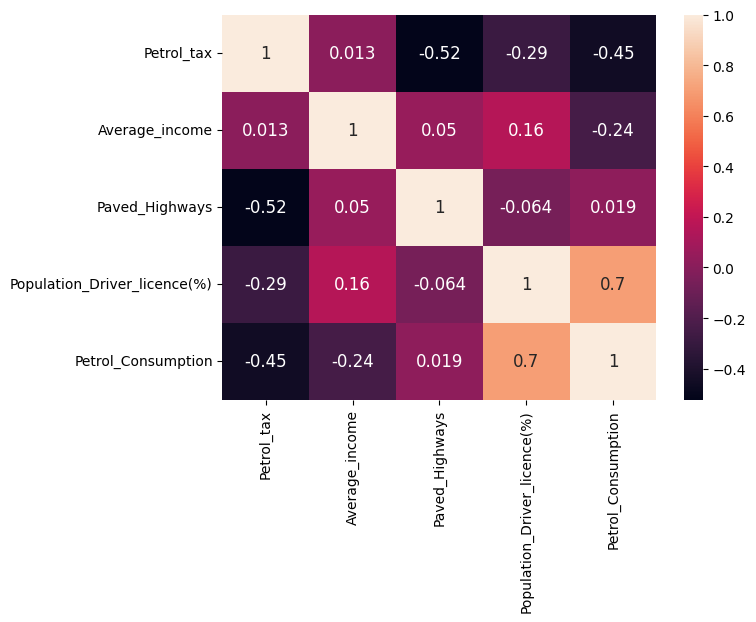

In [6]:
corrmat = dataset.corr()
plt.subplots(figsize = (7, 5))
sns.heatmap(corrmat, annot = True, annot_kws={'size': 12});

### Regression

In [7]:
X = dataset.drop('Petrol_Consumption', axis=1)
y = dataset['Petrol_Consumption']

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=667
                                                    )

In [9]:
from sklearn.tree import DecisionTreeRegressor

regressor = DecisionTreeRegressor()
regressor.fit(X_train, y_train)

DecisionTreeRegressor()

In [10]:
regressor.feature_importances_

array([0.05639179, 0.3517401 , 0.07558216, 0.51628595])

In [11]:
type(y_test)

pandas.core.series.Series

In [12]:
y_pred = regressor.predict(X_test)

In [13]:
df=pd.DataFrame({'reale':y_test, 'predetto':y_pred})
df

,reale,predetto
43,591,699.0
38,648,640.0
27,631,644.0
5,457,540.0
20,649,865.0
30,571,554.0
1,524,561.0
45,510,587.0
16,603,635.0
10,580,464.0


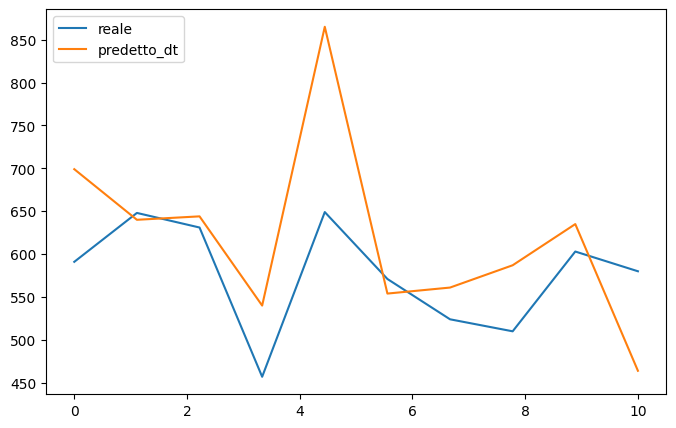

In [15]:
length = y_pred.shape[0] #
x = np.linspace(0,length,length)


plt.figure(figsize=(8,5))
plt.plot(x, y_test, label='reale')
plt.plot(x, y_pred, label='predetto_dt')
plt.legend(loc=2);

### Evaluating the Algorithm
To evaluate performance of the regression algorithm, the commonly used metrics are mean absolute error, mean squared error, and root mean squared error.

In [16]:
from sklearn import metrics
print('Mean Absolute Error (MAE):', metrics.mean_absolute_error(y_test, y_pred))
print('Mean Squared Error (MSE):', metrics.mean_squared_error(y_test, y_pred))
print('Root Mean Squared Error (RMSE):', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print('r2 score:',metrics.r2_score(y_test, y_pred))

Mean Absolute Error (MAE): 70.7
Mean Squared Error (MSE): 8750.9
Root Mean Squared Error (RMSE): 93.54624524800555
r2 score: -1.447639878721429


## With Linear Regression

In [17]:
from sklearn.linear_model import LinearRegression

regressor = LinearRegression()
regressor.fit(X_train, y_train)

LinearRegression()

In [18]:
regressor.coef_

array([-2.68598117e+01, -7.19837243e-02, -1.33713660e-03,  1.54064216e+03])

In [19]:
y_pred2 = regressor.predict(X_test)

In [20]:
df=pd.DataFrame({'reale':y_test, 'predetto_lr':y_pred2})
df

,reale,predetto_lr
43,591,538.959482
38,648,744.500987
27,631,619.020282
5,457,442.191356
20,649,709.732954
30,571,556.182530
1,524,560.682447
45,510,527.900483
16,603,596.490988
10,580,495.042321


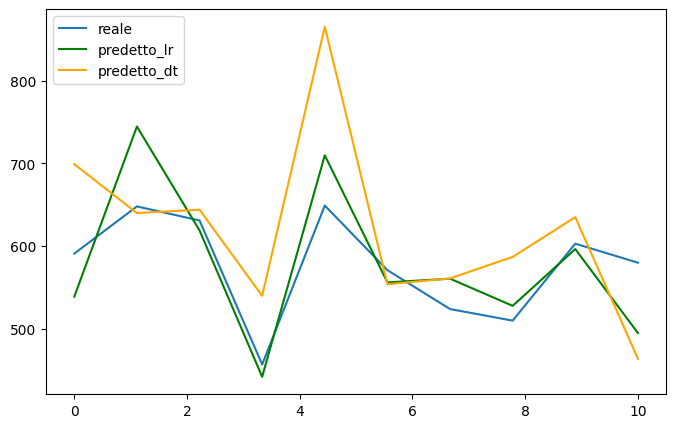

In [23]:
length = y_pred.shape[0] #
x = np.linspace(0,length,length)


plt.figure(figsize=(8,5))
plt.plot(x, y_test, label='reale')
plt.plot(x, y_pred2, label='predetto_lr',color='green')
plt.plot(x, y_pred, label='predetto_dt',color='orange')
plt.legend(loc=2);

In [24]:
from sklearn import metrics
print('Mean Absolute Error (MAE):', metrics.mean_absolute_error(y_test, y_pred2))
print('Mean Squared Error (MSE):', metrics.mean_squared_error(y_test, y_pred2))
print('Root Mean Squared Error (RMSE):', np.sqrt(metrics.mean_squared_error(y_test, y_pred2)))
print('r2 score:',metrics.r2_score(y_test, y_pred2))

Mean Absolute Error (MAE): 39.69299120343054
Mean Squared Error (MSE): 2521.7718319543173
Root Mean Squared Error (RMSE): 50.21724635973499
r2 score: 0.2946566294977909
